In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED = ROOT / "data" / "processed"
CHARTS = ROOT / "reports" / "charts"

fund_scorecard = pd.read_csv(PROCESSED / "fund_scorecard.csv")
nav = pd.read_csv(PROCESSED / "clean_nav.csv")
transactions = pd.read_csv(PROCESSED / "clean_transactions.csv")
sip = pd.read_csv(PROCESSED/"clean_sip_inflows.csv")
fund_master = pd.read_csv(PROCESSED/"clean_fund_master.csv")





,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score,risk_grade
0,102886,-0.132261,-0.018322,NaN,-0.296095,0.028969,-0.042125,-0.280011,1.51,38.0,37.0,40.0,24.5,35.0,100.000000,High
1,100016,-0.033055,-0.000316,NaN,-0.271960,0.037476,-0.058268,-0.247344,1.55,36.0,36.0,39.0,32.0,34.0,99.912968,High
2,119095,-0.454229,-0.110655,NaN,-0.200754,0.048016,-0.066951,-0.516778,1.38,40.0,34.0,37.0,17.0,39.0,94.865100,High
3,101207,-0.242421,-0.026965,NaN,0.044584,0.108971,-0.065289,-0.354469,1.53,39.0,30.0,27.0,28.5,38.0,89.033943,High
4,119092,0.034030,0.005560,NaN,-0.025941,0.068995,0.009731,-0.144016,1.64,35.0,32.0,30.0,39.5,15.0,86.422977,Moderate


# Historical VaR and CVaR

VaR (95%) estimates the maximum expected loss under normal market conditions.

CVaR measures the average loss beyond the VaR threshold.

In [4]:
nav.columns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

var = (
    nav.groupby("amfi_code")["daily_return"]
    .quantile(0.05)
)

cvar = (
    nav.groupby("amfi_code")["daily_return"]
    .apply(lambda x: x[x <= x.quantile(0.05)].mean())
)


In [5]:
risk_report = pd.DataFrame({
    "VaR_95": var,
    "CVaR": cvar
})

risk_report.to_csv(PROCESSED/"var_cvar_report.csv", index=False)

In [6]:
# Rolling Sharpe Ratio
#Measures risk-adjusted returns over a moving 90-day window.

annual_factor = np.sqrt(252)

nav["rolling_sharpe"] = (
    nav.groupby("amfi_code")["daily_return"]
    .transform(
        lambda x:
        (
            x.rolling(90).mean()
            /
            x.rolling(90).std()
        )
        * annual_factor
    )
)

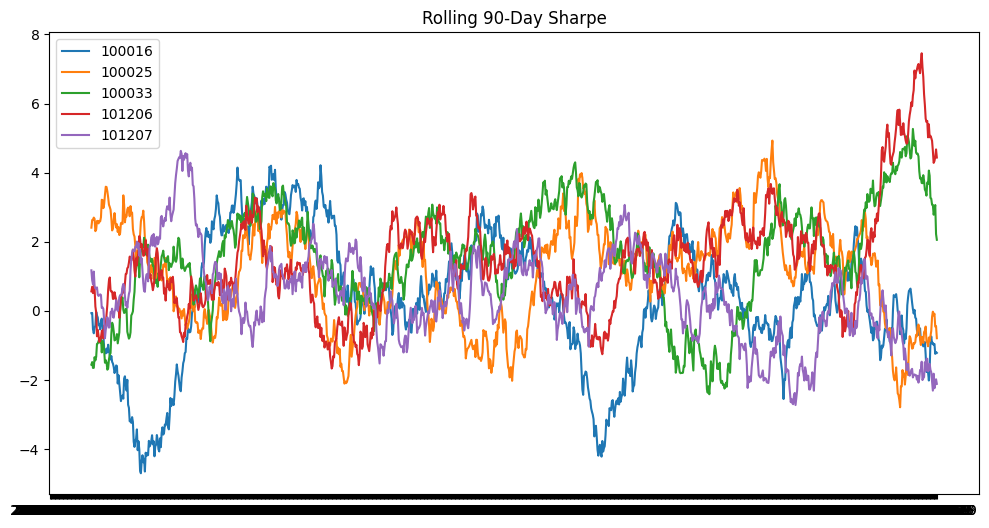

In [7]:
top5 = nav["amfi_code"].unique()[:5]
plt.figure(figsize=(12,6))

for fund in top5:
    subset = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        subset["date"],
        subset["rolling_sharpe"],
        label=fund
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe")

plt.savefig(
    CHARTS/"rolling_sharpe_chart.png"
)

plt.show()

In [8]:
#investor cohort analysis - investors grouoed by their first investment year
transactions["transaction_date"]=pd.to_datetime(transactions["transaction_date"])

transactions["cohort"] = (
    transactions.groupby("investor_id")
    ["transaction_date"]
    .transform("min")
    .dt.year
)




In [9]:
#cohort summary
cohort_summary = (
    transactions
    .groupby("cohort")
    .agg(
        avg_sip=("amount_inr","mean"),
        total_invested=("amount_inr","sum")
    )
)

cohort_summary

,avg_sip,total_invested
cohort,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [10]:
#sip continuity analysis 

sip_txn = transactions[
    transactions["transaction_type"] == "Sip"
]
sip_txn = sip_txn.sort_values(
    ["investor_id",
     "transaction_date"]
)
sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)
at_risk = sip_txn[
    sip_txn["gap_days"] > 35
]

len(at_risk)



9913

# Key Insights

- Certain schemes exhibit significantly higher downside risk based on CVaR.

- Rolling Sharpe ratios fluctuate considerably during volatile periods.

- Younger investor cohorts contribute higher transaction volumes.

- Several investors show SIP gaps exceeding 35 days and may require intervention.

In [ ]:
fund_scorecard["risk_grade"] = pd.qcut(
    fund_scorecard["max_drawdown"].abs(),
    q=3,
    labels=["Low", "Moderate", "High"]
)
fund_scorecard["risk_grade"].value_counts()





,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,...,expense_rank,drawdown_rank,fund_score,risk_grade,scheme_name_x,category_x,scheme_name_y,category_y,scheme_name,category
0,102886,-0.132261,-0.018322,NaN,-0.296095,0.028969,-0.042125,-0.280011,1.51,38.0,...,24.5,35.0,100.000000,High,UTI Mid Cap Fund - Regular - Growth,Equity,UTI Mid Cap Fund - Regular - Growth,Equity,UTI Mid Cap Fund - Regular - Growth,Equity
1,100016,-0.033055,-0.000316,NaN,-0.271960,0.037476,-0.058268,-0.247344,1.55,36.0,...,32.0,34.0,99.912968,High,HDFC Top 100 Fund - Regular Plan - Growth,Equity,HDFC Top 100 Fund - Regular Plan - Growth,Equity,HDFC Top 100 Fund - Regular Plan - Growth,Equity
2,119095,-0.454229,-0.110655,NaN,-0.200754,0.048016,-0.066951,-0.516778,1.38,40.0,...,17.0,39.0,94.865100,High,Axis Small Cap Fund - Regular - Growth,Equity,Axis Small Cap Fund - Regular - Growth,Equity,Axis Small Cap Fund - Regular - Growth,Equity
3,101207,-0.242421,-0.026965,NaN,0.044584,0.108971,-0.065289,-0.354469,1.53,39.0,...,28.5,38.0,89.033943,High,ABSL Small Cap Fund - Regular - Growth,Equity,ABSL Small Cap Fund - Regular - Growth,Equity,ABSL Small Cap Fund - Regular - Growth,Equity
4,119092,0.034030,0.005560,NaN,-0.025941,0.068995,0.009731,-0.144016,1.64,35.0,...,39.5,15.0,86.422977,Moderate,Axis Bluechip Fund - Regular - Growth,Equity,Axis Bluechip Fund - Regular - Growth,Equity,Axis Bluechip Fund - Regular - Growth,Equity


In [ ]:

fund_scorecard = fund_scorecard.merge(
    fund_master[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code',
    how='left'
)


MergeError: Passing 'suffixes' which cause duplicate columns {'scheme_name_y', 'category_x', 'category_y', 'scheme_name_x'} is not allowed.

In [27]:
fund_scorecard.drop(
    columns=[
        "scheme_name_x",
        "category_x",
    ],
    inplace=True
)


In [28]:
fund_scorecard.to_csv(PROCESSED / "fund_scorecard.csv",index=False)